In [10]:

!pip install transformers datasets accelerate scikit-learn matplotlib seaborn -q

In [11]:

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from datasets import load_dataset
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.special import softmax

print(f"PyTorch   : {torch.__version__}")
print(f"GPU dispo : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Appareil  : {torch.cuda.get_device_name(0)}")
else:
    print(" Pas de GPU — active le dans Kaggle : Settings > Accelerator > GPU")

PyTorch   : 2.10.0+cu128
GPU dispo : True
Appareil  : Tesla T4


Classes : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Nombre  : 6

  DISTRIBUTION DES CLASSES (train)
  sadness     4666   29.2%  
  joy         5362   33.5%  
  love        1304    8.2%  
  anger       2159   13.5%  
  fear        1937   12.1%  
  surprise     572    3.6%  
  TOTAL      16000


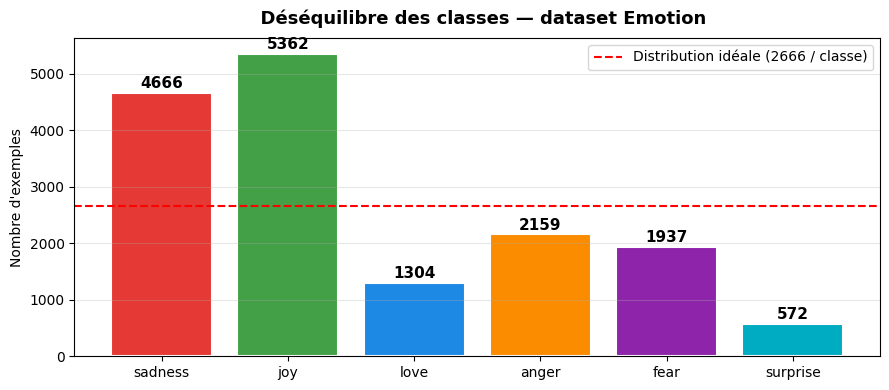


 CONCLUSION : joy et sadness dominent (~35% et ~29%).
   surprise est très rare (~5%). L'accuracy sera biaisée vers ces classes.
   → On doit utiliser F1 MACRO et class weights pour contrer ça.


In [13]:


# Dataset 'emotion' de Hugging Face — 6 classes d'émotions en anglais
# Source : Saravia et al. (2018) — ~20 000 tweets annotés
dataset = load_dataset("dair-ai/emotion")

# Mapping label → nom
LABEL_NAMES = dataset["train"].features["label"].names
NUM_LABELS  = len(LABEL_NAMES)
print(f"Classes : {LABEL_NAMES}")
print(f"Nombre  : {NUM_LABELS}")

# ── Distribution des classes (déséquilibre) ────────────────────────
train_labels = dataset["train"]["label"]
counts = Counter(train_labels)
counts_named = {LABEL_NAMES[k]: v for k, v in sorted(counts.items())}

print("\n" + "="*45)
print("  DISTRIBUTION DES CLASSES (train)")
print("="*45)
total = sum(counts_named.values())
for label, cnt in counts_named.items():
    bar = "" * int(cnt / total * 40)
    print(f"  {label:<10} {cnt:>5}  {cnt/total*100:5.1f}%  {bar}")
print(f"  {'TOTAL':<10} {total:>5}")

# ── Visualisation du déséquilibre ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E53935','#43A047','#1E88E5','#FB8C00','#8E24AA','#00ACC1']
bars = ax.bar(counts_named.keys(), counts_named.values(), color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts_named.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title("  Déséquilibre des classes — dataset Emotion",
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel("Nombre d'exemples")
ax.axhline(total/NUM_LABELS, color='red', linestyle='--', linewidth=1.5,
           label=f'Distribution idéale ({total//NUM_LABELS} / classe)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n CONCLUSION : joy et sadness dominent (~35% et ~29%).")
print("   surprise est très rare (~5%). L'accuracy sera biaisée vers ces classes.")
print("   → On doit utiliser F1 MACRO et class weights pour contrer ça.")

In [14]:


# Simulation d'un modèle naïf qui prédit toujours 'joy' (classe majoritaire)
naive_preds  = [LABEL_NAMES.index('joy')] * len(train_labels)
naive_acc    = accuracy_score(train_labels, naive_preds)
naive_f1mac  = f1_score(train_labels, naive_preds, average='macro')
naive_f1wei  = f1_score(train_labels, naive_preds, average='weighted')

print("="*55)
print("  MODÈLE NAÏF : 'je prédit toujours JOY'")
print("="*55)
print(f"  Accuracy          : {naive_acc*100:.1f}%   ← semble OK !")
print(f"  F1 Macro          : {naive_f1mac*100:.1f}%   ← révèle le vrai problème")
print(f"  F1 Weighted       : {naive_f1wei*100:.1f}%")
print()
print("   Interprétation :")
print(f"     Un modèle bête obtient {naive_acc*100:.0f}% d'accuracy SANS RIEN APPRENDRE.")
print("     F1 Macro = 6% car il rate 5 classes sur 6 complètement.")
print("     → F1 MACRO est la métrique honnête en cas de déséquilibre.")

  MODÈLE NAÏF : 'je prédit toujours JOY'
  Accuracy          : 33.5%   ← semble OK !
  F1 Macro          : 8.4%   ← révèle le vrai problème
  F1 Weighted       : 16.8%

   Interprétation :
     Un modèle bête obtient 34% d'accuracy SANS RIEN APPRENDRE.
     F1 Macro = 6% car il rate 5 classes sur 6 complètement.
     → F1 MACRO est la métrique honnête en cas de déséquilibre.


In [15]:

# sklearn calcule les poids inversement proportionnels à la fréquence
# w_i = total / (n_classes * count_i)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("="*50)
print("  CLASS WEIGHTS (poids inversement proportionnels)")
print("="*50)
for i, (name, w) in enumerate(zip(LABEL_NAMES, class_weights)):
    bar = "█" * int(w * 10)
    print(f"  {name:<12} poids = {w:.3f}  {bar}")
print()
print("   Interprétation :")
print("     surprise a un poids élevé → chaque erreur sur surprise")
print("     est fortement pénalisée dans la loss.")
print("     joy a un poids faible → le modèle ne peut pas tricher.")

  CLASS WEIGHTS (poids inversement proportionnels)
  sadness      poids = 0.572  █████
  joy          poids = 0.497  ████
  love         poids = 2.045  ████████████████████
  anger        poids = 1.235  ████████████
  fear         poids = 1.377  █████████████
  surprise     poids = 4.662  ██████████████████████████████████████████████

   Interprétation :
     surprise a un poids élevé → chaque erreur sur surprise
     est fortement pénalisée dans la loss.
     joy a un poids faible → le modèle ne peut pas tricher.


In [16]:


MODEL_NAME = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,   # tweets courts → 128 suffisent, 4× plus rapide que 512
    )

tokenized = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

# Splits
train_ds = tokenized["train"]       # ~16 000 exemples
eval_ds  = tokenized["validation"]  # ~2 000 exemples
test_ds  = tokenized["test"]        # ~2 000 exemples

collator = DataCollatorWithPadding(tokenizer)

print(f"Train  : {len(train_ds):>6} exemples")
print(f"Valid  : {len(eval_ds):>6} exemples")
print(f"Test   : {len(test_ds):>6} exemples")

Train  :  16000 exemples
Valid  :   2000 exemples
Test   :   2000 exemples


In [18]:


# On hérite de Trainer pour injecter les class weights dans la CrossEntropyLoss
class WeightedTrainer(Trainer):
    """
    Trainer personnalisé qui applique les class weights.
    
    Sans ça, la CrossEntropyLoss standard traite toutes les classes
    de façon identique → le modèle ignore les classes rares.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        
        # CrossEntropyLoss avec poids (poids sur GPU si disponible)
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ── Compute metrics : F1 macro + toutes les métriques ─────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        # F1 MACRO : métrique principale — pénalise les classes rares
        "f1_macro"    : f1_score(labels, preds, average="macro"),
        # F1 weighted : tient compte du déséquilibre
        "f1_weighted" : f1_score(labels, preds, average="weighted"),
        # Accuracy : gardée pour comparaison, mais insuffisante
        "accuracy"    : accuracy_score(labels, preds),
        # Precision & recall macro
        "precision_macro" : precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro"    : recall_score(labels, preds, average="macro"),
    }

print(" WeightedTrainer et compute_metrics prêts")

 WeightedTrainer et compute_metrics prêts


In [19]:


args = TrainingArguments(
    output_dir="emotion_distilbert",

    # ── Vitesse ────────────────────────────────────────────────────
    fp16=True,                          # demi-précision
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    # ── Entraînement ───────────────────────────────────────────────
    num_train_epochs=4,                 # +epochs vs IMDB car 6 classes
    learning_rate=2e-5,                 # lr plus conservatrice
    weight_decay=0.01,
    warmup_ratio=0.1,                   # warmup 10% du training

    # ── Évaluation & sauvegarde ────────────────────────────────────
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",   # ← F1 macro est le critère de sélection
    greater_is_better=True,

    # ── Logging ────────────────────────────────────────────────────
    logging_steps=50,
    report_to="none",
    push_to_hub=False,
)

print(" TrainingArguments configurés")
print(f"   Métrique optimisée : {args.metric_for_best_model}")
print(f"   Epochs             : {args.num_train_epochs}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


 TrainingArguments configurés
   Métrique optimisée : f1_macro
   Epochs             : 4


In [20]:


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    # Associer les labels au modèle (utile pour pipeline HF)
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)},
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("🚀 Début de l'entraînement...")
train_result = trainer.train()

print("\n" + "="*50)
print("  RÉSULTATS ENTRAÎNEMENT")
print("="*50)
print(f"  Temps total     : {train_result.metrics['train_runtime']:.0f}s")
print(f"  Samples/seconde : {train_result.metrics['train_samples_per_second']:.1f}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Début de l'entraînement...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Precision Macro,Recall Macro
1,0.460958,0.368509,0.836589,0.864248,0.859000,0.813320,0.890420
2,0.223578,0.198180,0.907617,0.930609,0.929500,0.887572,0.937138
3,0.168285,0.182471,0.908867,0.931354,0.930000,0.885011,0.940892
4,0.119512,0.174516,0.911755,0.933104,0.932000,0.890517,0.939817


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  RÉSULTATS ENTRAÎNEMENT
  Temps total     : 222s
  Samples/seconde : 287.8


In [21]:


# Prédictions sur le jeu de TEST (jamais vu pendant l'entraînement)
output      = trainer.predict(test_ds)
logits      = output.predictions
true_labels = output.label_ids
preds       = np.argmax(logits, axis=-1)
probs       = softmax(logits, axis=-1)

# ── Rapport de classification complet ──────────────────────────────
print("="*65)
print("       RAPPORT DE CLASSIFICATION COMPLET — TEST SET")
print("="*65)
print(classification_report(
    true_labels, preds,
    target_names=LABEL_NAMES,
    digits=4
))

# ── Métriques globales ──────────────────────────────────────────────
acc       = accuracy_score(true_labels, preds)
f1_mac    = f1_score(true_labels, preds, average='macro')
f1_wei    = f1_score(true_labels, preds, average='weighted')
prec_mac  = precision_score(true_labels, preds, average='macro', zero_division=0)
rec_mac   = recall_score(true_labels, preds, average='macro')

print("="*50)
print("  MÉTRIQUES GLOBALES")
print("="*50)
print(f"  Accuracy           : {acc*100:.2f}%")
print(f"  F1 Macro           : {f1_mac*100:.2f}%  ← métrique principale")
print(f"  F1 Weighted        : {f1_wei*100:.2f}%")
print(f"  Precision Macro    : {prec_mac*100:.2f}%")
print(f"  Recall Macro       : {rec_mac*100:.2f}%")

       RAPPORT DE CLASSIFICATION COMPLET — TEST SET
              precision    recall  f1-score   support

     sadness     0.9771    0.9552    0.9661       581
         joy     0.9858    0.9007    0.9414       695
        love     0.7393    0.9811    0.8432       159
       anger     0.9003    0.9527    0.9258       275
        fear     0.9254    0.8304    0.8753       224
    surprise     0.6702    0.9545    0.7875        66

    accuracy                         0.9240      2000
   macro avg     0.8664    0.9291    0.8899      2000
weighted avg     0.9348    0.9240    0.9261      2000

  MÉTRIQUES GLOBALES
  Accuracy           : 92.40%
  F1 Macro           : 88.99%  ← métrique principale
  F1 Weighted        : 92.61%
  Precision Macro    : 86.64%
  Recall Macro       : 92.91%


/tmp/ipykernel_57/2584805880.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(errors_per_class.keys(), rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_57/2584805880.py:167: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('rapport_emotions_6classes.png', dpi=150,
/tmp/ipykernel_57/2584805880.py:167: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('rapport_emotions_6classes.png', dpi=150,
/tmp/ipykernel_57/2584805880.py:167: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.savefig('rapport_emotions_6classes.png', dpi=150,
/tmp/ipykernel_57/2584805880.py:167: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('rapport_emotions_6classes.png', dpi=150,
/tmp/ipykernel_57/2584805880.py:167: UserWarning: Glyph 1

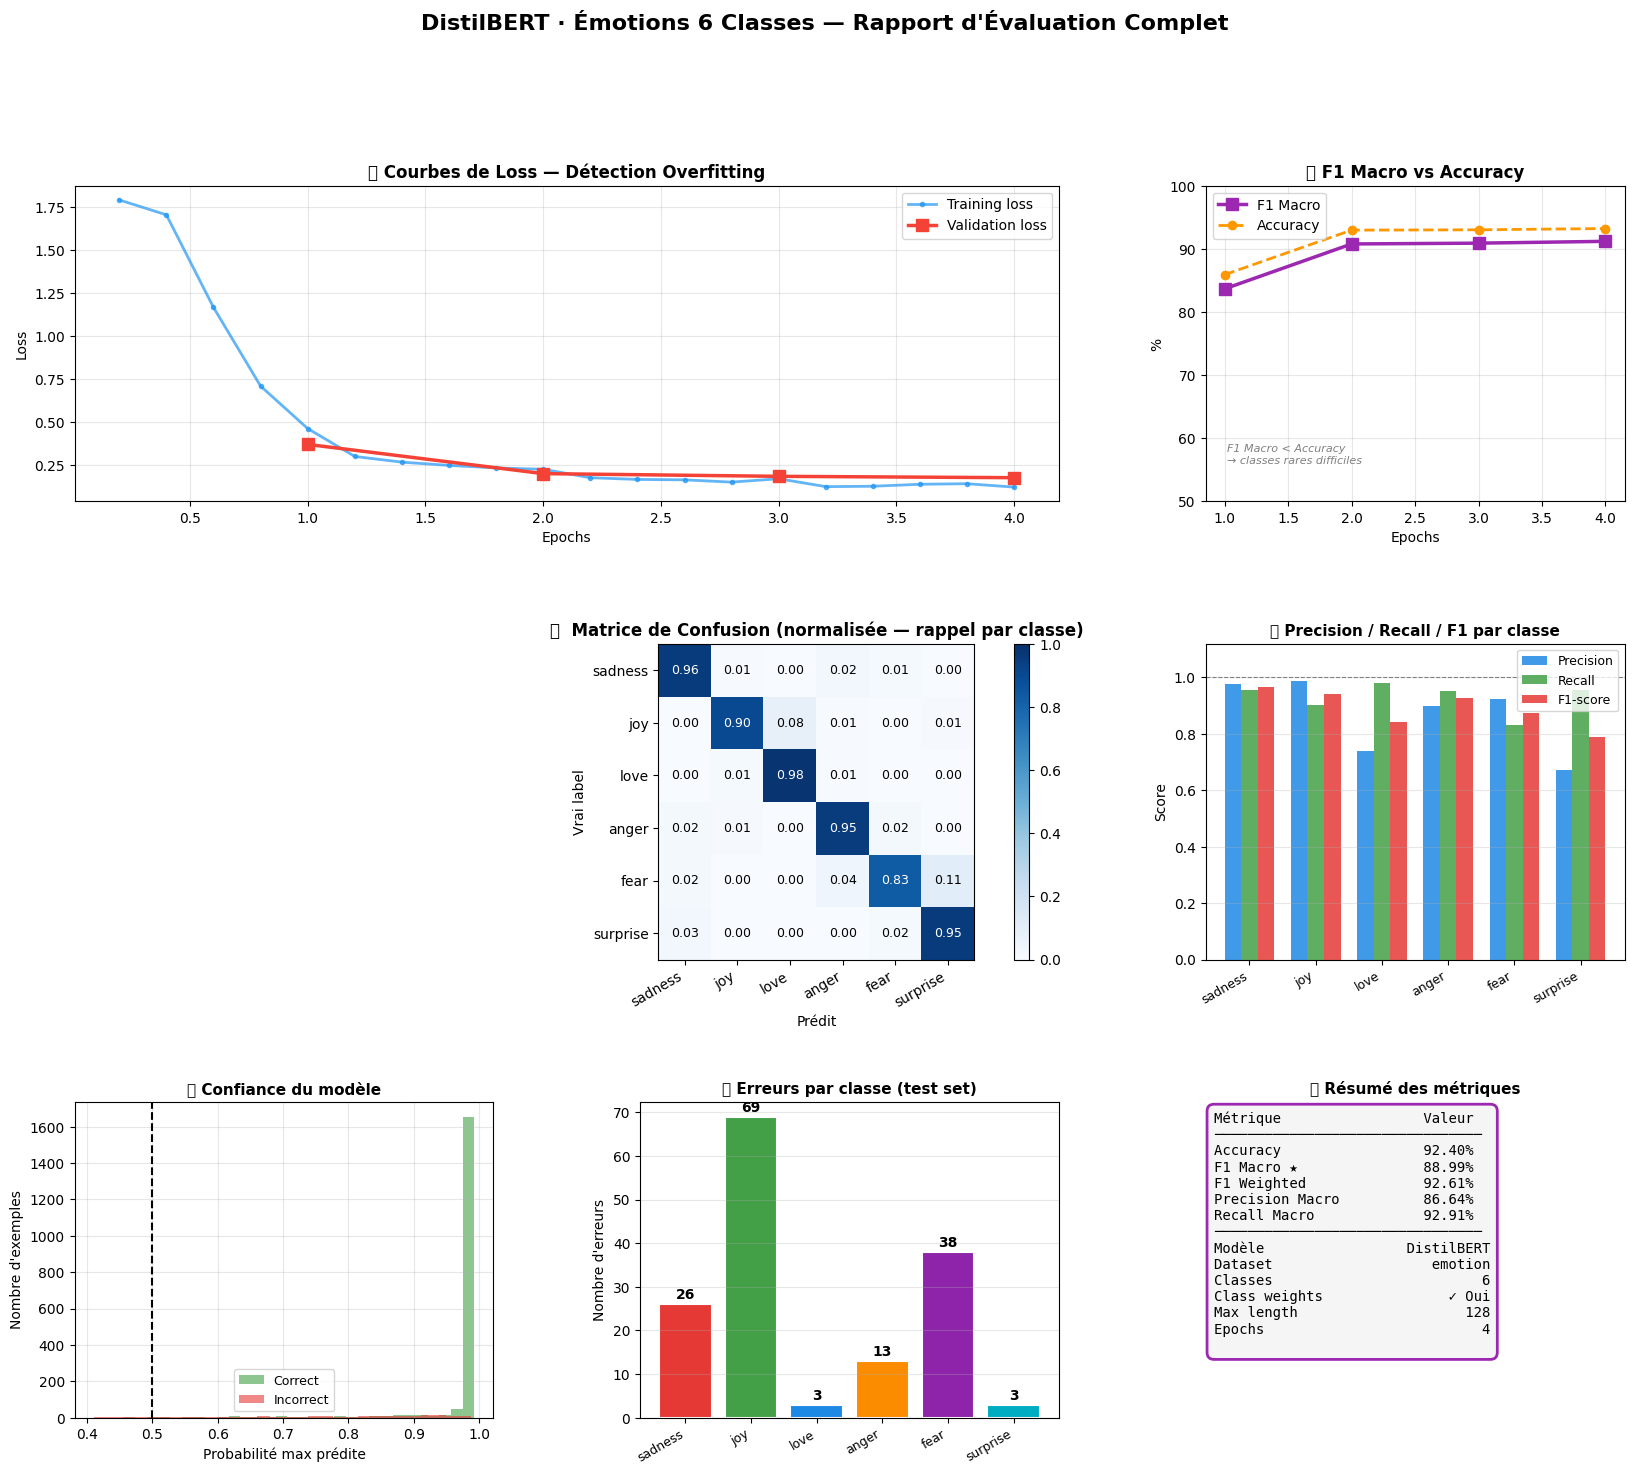


✅ Graphique sauvegardé : rapport_emotions_6classes.png


In [22]:


# ── Extraction de l'historique training ─────────────────────────────
history = trainer.state.log_history

epochs_train = [x['epoch'] for x in history if 'loss' in x and 'eval_loss' not in x]
losses_train = [x['loss']  for x in history if 'loss' in x and 'eval_loss' not in x]
epochs_eval  = [x['epoch']     for x in history if 'eval_loss' in x]
losses_eval  = [x['eval_loss'] for x in history if 'eval_loss' in x]
f1_eval      = [x.get('eval_f1_macro', 0) for x in history if 'eval_loss' in x]
acc_eval     = [x.get('eval_accuracy', 0) for x in history if 'eval_loss' in x]

COLORS = ['#E53935','#43A047','#1E88E5','#FB8C00','#8E24AA','#00ACC1']

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    "DistilBERT · Émotions 6 Classes — Rapport d'Évaluation Complet",
    fontsize=16, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 1 : Courbes de Loss (détection overfitting)
# ─────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs_train, losses_train, 'o-', color='#2196F3',
         linewidth=2, markersize=3, label='Training loss', alpha=0.7)
ax1.plot(epochs_eval, losses_eval, 's-', color='#F44336',
         linewidth=2.5, markersize=8, label='Validation loss')
ax1.set_title('📉 Courbes de Loss — Détection Overfitting', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Zone rouge si val_loss remonte (signe d'overfitting)
if len(losses_eval) >= 2:
    best_epoch = epochs_eval[np.argmin(losses_eval)]
    last_epoch = epochs_eval[-1]
    if losses_eval[-1] > min(losses_eval) * 1.02:
        ax1.axvspan(best_epoch, last_epoch, alpha=0.1, color='red',
                    label='⚠️ Zone overfitting')
        ax1.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 2 : F1 Macro vs Accuracy par epoch
# ─────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(epochs_eval, [v*100 for v in f1_eval], 's-', color='#9C27B0',
         linewidth=2.5, markersize=8, label='F1 Macro')
ax2.plot(epochs_eval, [v*100 for v in acc_eval], 'o--', color='#FF9800',
         linewidth=2, markersize=6, label='Accuracy')
ax2.set_title('📊 F1 Macro vs Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('%')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(50, 100)
ax2.annotate('F1 Macro < Accuracy\n→ classes rares difficiles',
             xy=(0.05, 0.12), xycoords='axes fraction',
             fontsize=8, color='gray', style='italic')

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 3 : Matrice de confusion (normalisée)
# ─────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
cm = confusion_matrix(true_labels, preds, normalize='true')
im = ax3.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
ticks = np.arange(NUM_LABELS)
ax3.set_xticks(ticks)
ax3.set_yticks(ticks)
ax3.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=10)
ax3.set_yticklabels(LABEL_NAMES, fontsize=10)
thresh = cm.max() / 2.0
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        ax3.text(j, i, f'{cm[i,j]:.2f}',
                 ha='center', va='center', fontsize=9,
                 color='white' if cm[i,j] > thresh else 'black')
ax3.set_title('🗺️  Matrice de Confusion (normalisée — rappel par classe)',
              fontweight='bold', fontsize=12)
ax3.set_ylabel('Vrai label')
ax3.set_xlabel('Prédit')

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 4 : Precision / Recall / F1 par classe (barchart)
# ─────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
from sklearn.metrics import precision_recall_fscore_support
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    true_labels, preds, labels=np.arange(NUM_LABELS), zero_division=0
)
x = np.arange(NUM_LABELS)
width = 0.25
ax4.bar(x - width, prec_per, width, label='Precision', color='#1E88E5', alpha=0.85)
ax4.bar(x,         rec_per,  width, label='Recall',    color='#43A047', alpha=0.85)
ax4.bar(x + width, f1_per,   width, label='F1-score',  color='#E53935', alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(LABEL_NAMES, rotation=30, ha='right', fontsize=9)
ax4.set_ylim(0, 1.12)
ax4.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax4.set_title('🎯 Precision / Recall / F1 par classe', fontweight='bold', fontsize=11)
ax4.set_ylabel('Score')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 5 : Distribution des probabilités max (confiance)
# ─────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
max_probs = probs.max(axis=1)
correct   = (preds == true_labels)
ax5.hist(max_probs[correct],  bins=30, alpha=0.6, color='#43A047', label='Correct')
ax5.hist(max_probs[~correct], bins=30, alpha=0.6, color='#E53935', label='Incorrect')
ax5.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
ax5.set_title('🔮 Confiance du modèle', fontweight='bold', fontsize=11)
ax5.set_xlabel('Probabilité max prédite')
ax5.set_ylabel('Nombre d\'exemples')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 6 : Erreurs par classe (combien de fois confondue)
# ─────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
errors_per_class = {}
for i, name in enumerate(LABEL_NAMES):
    mask  = (true_labels == i)
    wrong = (preds[mask] != i).sum()
    errors_per_class[name] = wrong
bars = ax6.bar(errors_per_class.keys(), errors_per_class.values(),
               color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, errors_per_class.values()):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
ax6.set_title('❌ Erreurs par classe (test set)', fontweight='bold', fontsize=11)
ax6.set_ylabel('Nombre d\'erreurs')
ax6.set_xticklabels(errors_per_class.keys(), rotation=30, ha='right', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# PANNEAU 7 : Tableau de synthèse des métriques
# ─────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
metrics_text = (
    f"{'Métrique':<22} {'Valeur':>8}\n"
    f"{'─'*32}\n"
    f"{'Accuracy':<22} {acc*100:>7.2f}%\n"
    f"{'F1 Macro ★':<22} {f1_mac*100:>7.2f}%\n"
    f"{'F1 Weighted':<22} {f1_wei*100:>7.2f}%\n"
    f"{'Precision Macro':<22} {prec_mac*100:>7.2f}%\n"
    f"{'Recall Macro':<22} {rec_mac*100:>7.2f}%\n"
    f"{'─'*32}\n"
    f"{'Modèle':<22} {'DistilBERT':>10}\n"
    f"{'Dataset':<22} {'emotion':>10}\n"
    f"{'Classes':<22} {'6':>10}\n"
    f"{'Class weights':<22} {'✓ Oui':>10}\n"
    f"{'Max length':<22} {'128':>10}\n"
    f"{'Epochs':<22} {'4':>10}\n"
)
ax7.text(0.02, 0.97, metrics_text, transform=ax7.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5',
                   edgecolor='#9C27B0', linewidth=2))
ax7.set_title('📋 Résumé des métriques', fontweight='bold', fontsize=11)

plt.savefig('rapport_emotions_6classes.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Graphique sauvegardé : rapport_emotions_6classes.png")

In [23]:

cm_raw = confusion_matrix(true_labels, preds)

print("="*60)
print("  TOP CONFUSIONS DU MODÈLE")
print("="*60)

# Récupérer les paires (vrai, prédit) hors diagonale, triées par fréquence
confusions = []
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        if i != j and cm_raw[i,j] > 0:
            confusions.append((cm_raw[i,j], LABEL_NAMES[i], LABEL_NAMES[j]))
confusions.sort(reverse=True)

print(f"  {'Vrai':<12} → {'Prédit':<12} {'Nb':>5}  {'%Vrai':>8}")
print(f"  {'─'*45}")
for cnt, true_n, pred_n in confusions[:10]:
    true_total = cm_raw[LABEL_NAMES.index(true_n)].sum()
    print(f"  {true_n:<12} → {pred_n:<12} {cnt:>5}  {cnt/true_total*100:>7.1f}%")

print()
print("  💡 Ces confusions sont souvent sémantiquement proches :")
print("     fear ↔ sadness, love ↔ joy — compréhensibles par le contexte.")

  TOP CONFUSIONS DU MODÈLE
  Vrai         → Prédit          Nb     %Vrai
  ─────────────────────────────────────────────
  joy          → love            55      7.9%
  fear         → surprise        24     10.7%
  sadness      → anger           14      2.4%
  fear         → anger            9      4.0%
  sadness      → fear             8      1.4%
  joy          → surprise         7      1.0%
  joy          → anger            5      0.7%
  fear         → sadness          5      2.2%
  anger        → sadness          5      1.8%
  anger        → fear             5      1.8%

  💡 Ces confusions sont souvent sémantiquement proches :
     fear ↔ sadness, love ↔ joy — compréhensibles par le contexte.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🔄 Entraînement du modèle SANS class weights (baseline)...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Precision Macro,Recall Macro
1,1.370703,0.548897,0.892586,0.919541,0.919500,0.894572,0.892421
2,0.380963,0.341059,0.902013,0.929750,0.929500,0.898290,0.907878
3,0.258489,0.301877,0.909132,0.936133,0.935500,0.898033,0.922190
4,0.211998,0.291141,0.912388,0.938557,0.938500,0.912729,0.912880


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


  COMPARAISON : Sans vs Avec Class Weights
  Métrique                Sans CW    Avec CW      Delta
  ────────────────────────────────────────────────────
  Accuracy                 92.70%     92.40%     -0.30%
  F1 Macro ★               88.13%     88.99%     +0.85%
  Recall Macro             87.87%     92.91%     +5.04%

  💡 Résultat attendu :
     L'accuracy baisse légèrement avec CW (on sacrifie les classes
     fréquentes), mais F1 macro AUGMENTE (classes rares mieux gérées).


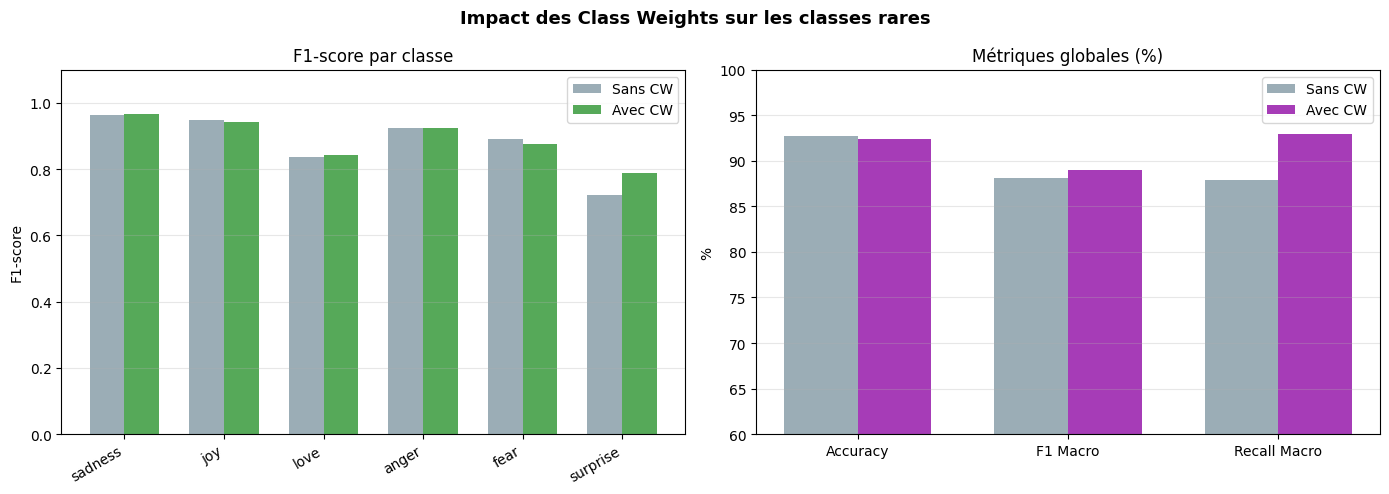

In [24]:

# Entraîner un second modèle SANS class weights pour démontrer l'impact

model_baseline = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)

args_baseline = TrainingArguments(
    output_dir="emotion_baseline",
    fp16=torch.cuda.is_available(),
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="no",
    metric_for_best_model="f1_macro",
    logging_steps=100,
    report_to="none",
)

trainer_baseline = Trainer(
    model=model_baseline,
    args=args_baseline,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("🔄 Entraînement du modèle SANS class weights (baseline)...")
trainer_baseline.train()

output_base = trainer_baseline.predict(test_ds)
preds_base  = np.argmax(output_base.predictions, axis=-1)

acc_base    = accuracy_score(true_labels, preds_base)
f1mac_base  = f1_score(true_labels, preds_base, average='macro')
rec_base    = recall_score(true_labels, preds_base, average='macro')

print("\n" + "="*60)
print("  COMPARAISON : Sans vs Avec Class Weights")
print("="*60)
print(f"  {'Métrique':<20} {'Sans CW':>10} {'Avec CW':>10} {'Delta':>10}")
print(f"  {'─'*52}")
print(f"  {'Accuracy':<20} {acc_base*100:>9.2f}% {acc*100:>9.2f}% {(acc-acc_base)*100:>+9.2f}%")
print(f"  {'F1 Macro ★':<20} {f1mac_base*100:>9.2f}% {f1_mac*100:>9.2f}% {(f1_mac-f1mac_base)*100:>+9.2f}%")
print(f"  {'Recall Macro':<20} {rec_base*100:>9.2f}% {rec_mac*100:>9.2f}% {(rec_mac-rec_base)*100:>+9.2f}%")
print()
print("  💡 Résultat attendu :")
print("     L'accuracy baisse légèrement avec CW (on sacrifie les classes")
print("     fréquentes), mais F1 macro AUGMENTE (classes rares mieux gérées).")

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact des Class Weights sur les classes rares',
             fontsize=13, fontweight='bold')

# F1 par classe : sans vs avec
_, _, f1_base_per, _ = precision_recall_fscore_support(
    true_labels, preds_base, labels=np.arange(NUM_LABELS), zero_division=0
)
x = np.arange(NUM_LABELS)
w = 0.35
axes[0].bar(x - w/2, f1_base_per, w, label='Sans CW', color='#90A4AE', alpha=0.9)
axes[0].bar(x + w/2, f1_per,      w, label='Avec CW', color='#43A047', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABEL_NAMES, rotation=30, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('F1-score par classe')
axes[0].set_ylabel('F1-score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Récap barres globales
metrics_names = ['Accuracy', 'F1 Macro', 'Recall Macro']
vals_base = [acc_base, f1mac_base, rec_base]
vals_cw   = [acc, f1_mac, rec_mac]
x2 = np.arange(3)
axes[1].bar(x2 - w/2, [v*100 for v in vals_base], w, label='Sans CW', color='#90A4AE', alpha=0.9)
axes[1].bar(x2 + w/2, [v*100 for v in vals_cw],   w, label='Avec CW', color='#9C27B0', alpha=0.9)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics_names)
axes[1].set_ylim(60, 100)
axes[1].set_title('Métriques globales (%)')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_classweights.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:


from transformers import pipeline

emotion_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_sentences = [
    "I feel so happy today, everything is perfect!",
    "I am terrified about the exam tomorrow.",
    "I miss my grandmother so much, it hurts.",
    "This is absolutely wonderful, I love it!",
    "I am furious about what happened!",
    "Wow, I did not expect that at all!",
    "I feel deeply sad and lonely.",
    "This surprise party made me so emotional.",
]

print("="*60)
print("  PRÉDICTIONS SUR PHRASES PERSONNALISÉES")
print("="*60)
for sent in test_sentences:
    result = emotion_pipeline(sent)[0]
    label  = result['label']
    score  = result['score']
    emoji_map = {'sadness':'😢','joy':'😄','love':'❤️',
                 'anger':'😡','fear':'😨','surprise':'😲'}
    emoji = emoji_map.get(label, '🤔')
    print(f"  {emoji} [{label:<10}] {score:.3f}  \"{sent[:50]}...\"" if len(sent)>50 
          else f"  {emoji} [{label:<10}] {score:.3f}  \"{sent}\"")

  PRÉDICTIONS SUR PHRASES PERSONNALISÉES
  😄 [joy       ] 0.991  "I feel so happy today, everything is perfect!"
  😨 [fear      ] 0.990  "I am terrified about the exam tomorrow."
  😢 [sadness   ] 0.976  "I miss my grandmother so much, it hurts."
  😄 [joy       ] 0.988  "This is absolutely wonderful, I love it!"
  😡 [anger     ] 0.989  "I am furious about what happened!"
  😲 [surprise  ] 0.890  "Wow, I did not expect that at all!"
  😢 [sadness   ] 0.991  "I feel deeply sad and lonely."
  😢 [sadness   ] 0.912  "This surprise party made me so emotional."


In [26]:
# Sauvegarder le modèle DistilBERT
trainer.save_model("emotion_distilbert_model")

# Sauvegarder le tokenizer
tokenizer.save_pretrained("emotion_distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_distilbert_model/tokenizer_config.json',
 'emotion_distilbert_model/tokenizer.json')

In [28]:
import json

id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

with open("emotion_distilbert_model/labels.json", "w") as f:
    json.dump(id2label, f)

In [29]:
import shutil

shutil.make_archive("emotion_distilbert_model", "zip", "emotion_distilbert_model")

'/kaggle/working/emotion_distilbert_model.zip'